In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import yfinance as yf

[*********************100%***********************]  1 of 1 completed


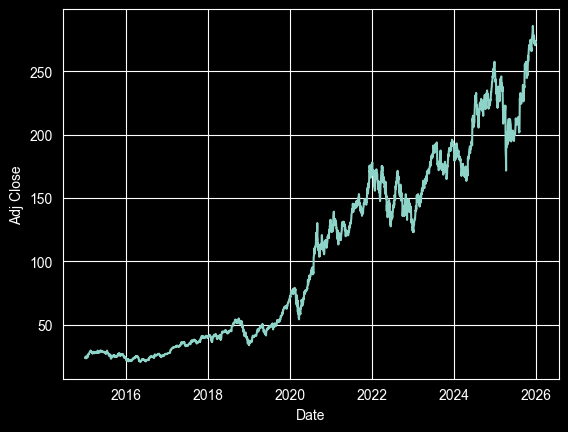

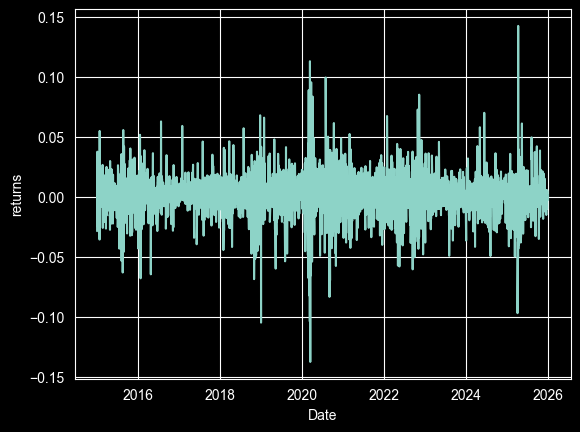

In [105]:
df = yf.download('AAPL',start='2015-01-01',end='2025-12-31',auto_adjust=False,multi_level_index=False)
df.drop(columns=['Close','High','Low','Open'], inplace=True)
df['returns'] = np.log(df['Adj Close']/df['Adj Close'].shift(1))
df.dropna(inplace=True)

sns.lineplot(df['Adj Close'])
plt.show()

sns.lineplot(df['returns'])
plt.show()
df['volatility'] = df['returns'].rolling(20).std()
df['lag1'] = df['returns'].shift(1)
df.dropna(inplace=True)
df = df[['returns','volatility','lag1']]

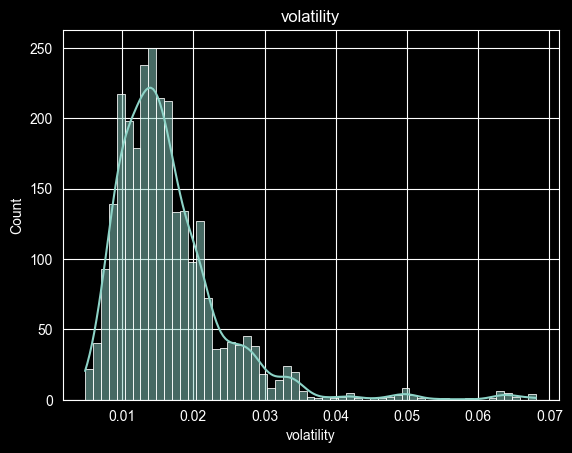

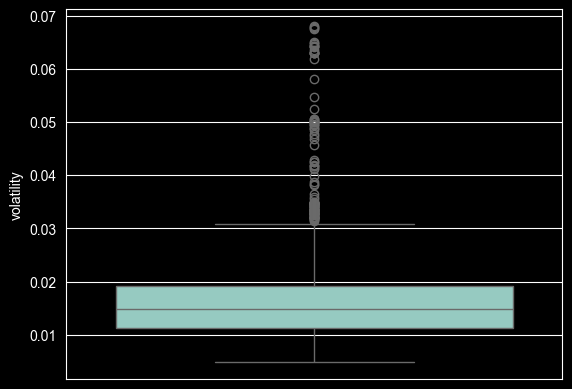

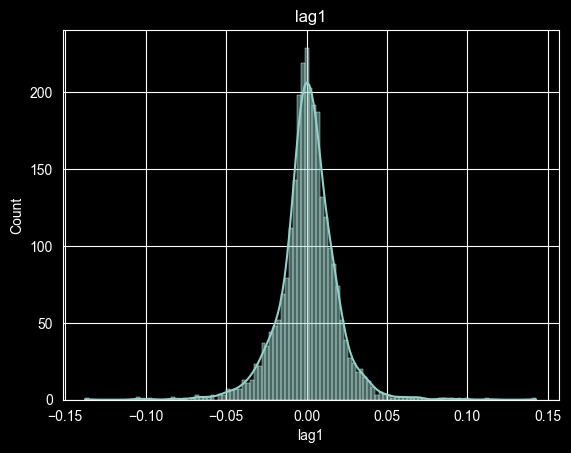

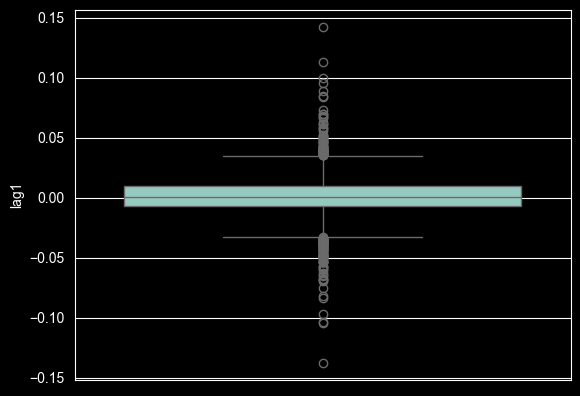

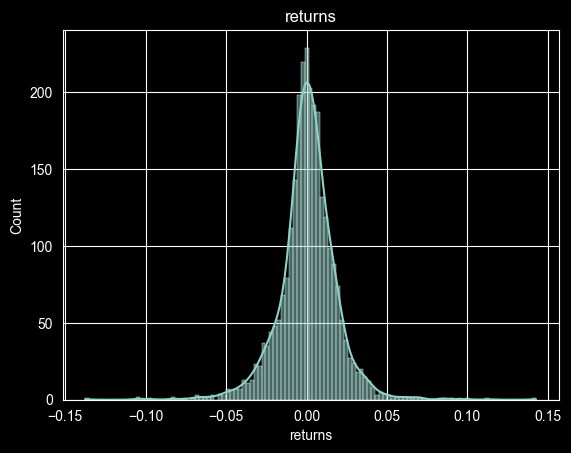

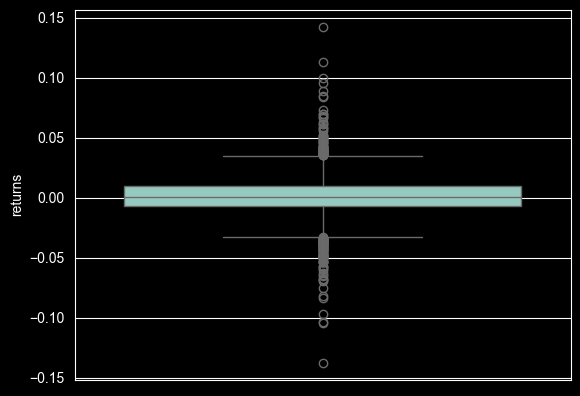

In [106]:
for col in ['volatility','lag1','returns']:
    sns.histplot(df[col],kde=True)
    plt.title(col)
    plt.show()

    sns.boxplot(df[col])
    plt.show()

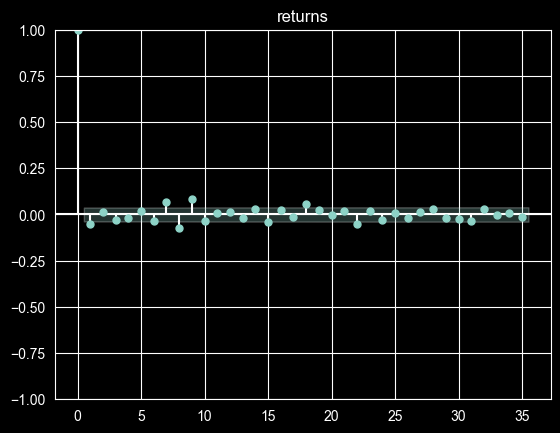

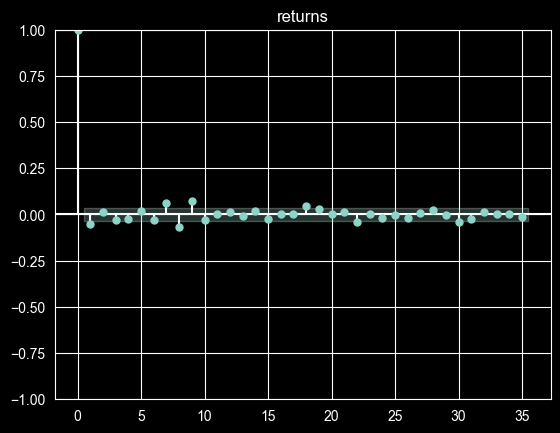

In [107]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller
plot_acf(df['returns'])
plt.title(col)
plt.show()

plot_pacf(df['returns'])
plt.title(col)
plt.show()

In [108]:
result = adfuller(df['returns'])
print("p-value",result[1])

p-value 1.772777401067721e-29


In [109]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[['volatility','lag1']]
y = df['returns']
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['vif'] = [variance_inflation_factor(X.values,i)for i in range (X.shape[1])]
print(vif_data)

      feature      vif
0  volatility  1.00134
1        lag1  1.00134


In [117]:
predictions = []
y_true = []

for i in range(window, len(df)):

    train = df.iloc[i-window:i, :]
    test = df.iloc[i:i+1, :]

    X_train = train[['volatility','lag1']]
    y_train = train['returns']

    X_test = test[['volatility','lag1']]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)[0]

    predictions.append(pred)
    y_true.append(test['returns'].values[0])  # 🔥 THIS LINE

In [118]:
print(model.predict(X_test_scaled).shape)

(1,)


In [120]:
print("Mean prediction:", np.mean(predictions))
print("Std prediction:", np.std(predictions))

Mean prediction: 0.0006469467868851581
Std prediction: 0.0037010054669784197


In [121]:
direction = (np.array(predictions) > 0) == (np.array(y_true) > 0)
accuracy = direction.mean()

print("Direction accuracy:", accuracy)

Direction accuracy: 0.5211881188118812


In [125]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
r2 = r2_score(y_true, predictions)
rmse = np.sqrt(mean_squared_error(y_true, predictions))
mae = mean_absolute_error(y_true, predictions)

print("r2 = ",r2)
print("rmse = ",rmse)
print("mae = ",mae)

r2 =  -0.03167941744297109
rmse =  0.018554176519167943
mae =  0.012668042175964598


In [126]:
import numpy as np
print("Mean abs return:", np.mean(np.abs(y_true)))

Mean abs return: 0.012569762421781604
